qsar slouží k tomu abychom se naučili jak moc dobře bude látky fungovat

In [1]:
import pandas as pd
from rdkit import Chem

df_train = pd.read_csv('dataset-QSAR_90pct_reduced.csv')

df_train.head()

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES
0,CWYBNSVSYKQGJB-UHFFFAOYNA-N,71541095,6532,A,6.85387,pubchem,727355,9606,SLC6A4,4061,ClC=1C=C(C2CCCCNC2)C=CC1Cl
1,FQDRMHHCWZAXJM-UHFFFAOYNA-N,125558,25553,A,9.98297,pubchem,205028,10116,SLC6A4,4061,O1C=2C=C3CC(N)CC3=CC2OC1
2,QRAWNNQNLQPNIZ-UHFFFAOYNA-N,CHEMBL205229,6532,A,7.54000,chembl20,950695,9606,SLC6A4,4061,N1C=C(CCN)C2=C1C(=CC=C2)F
3,HCFHWXDIZOAUTQ-UHFFFAOYNA-N,CHEMBL6376,25553,A,6.11000,chembl20,201505,10116,SLC6A4,4061,C1(=CC=2OCOC2C=C1C)CC(N)C
4,JBDOSUUXMYMWQH-UHFFFAOYNA-N,CHEMBL1381098,6532,A,5.12000,chembl20,774720,9606,SLC6A4,4061,S=C=NC=1C=2C(C=CC1)=CC=CC2


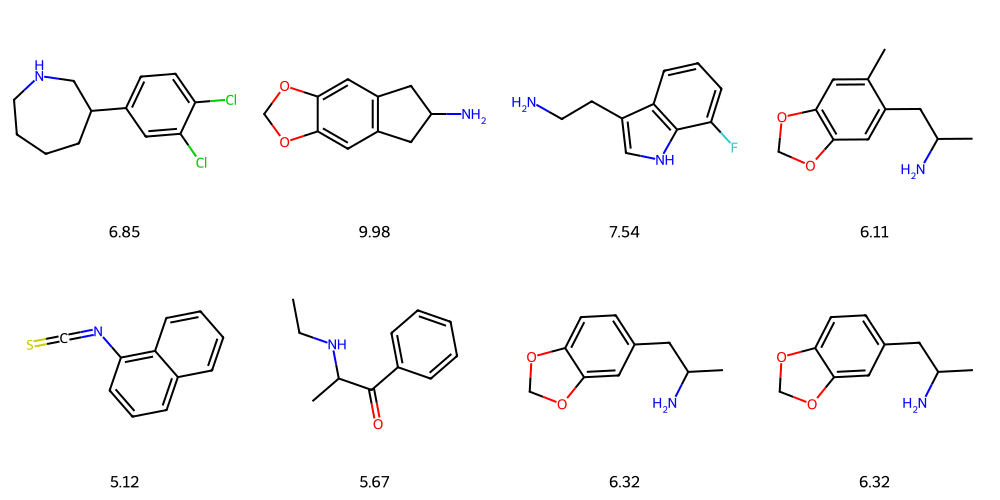

In [ ]:
# pxc50 říká jak dobře látka funguje(čím lepe tím mene toho musíme pacientovy dát)
# vykreslení podle smiles a zobrazení účinnosti
from rdkit.Chem import Draw

sample_smiles = df_train['SMILES'].head(8).tolist()

mols = [Chem.MolFromSmiles(smiles) for smiles in sample_smiles]

sample_pxc50 = df_train['pXC50'].head(8).round(2).astype(str).tolist()

img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250), legends=sample_pxc50)

img

In [3]:
# převedu na barcode a vytvířím jak bude vypadat trénovací dataset
import numpy as np
from rdkit.Chem import AllChem

def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

    return np.array(fp)

X_train = np.array([smiles_to_fp(s) for s in df_train['SMILES']])

y_train = df_train['pXC50'].values

print(f"Hotovo! Máme připraveno {X_train.shape[0]} molekul.")
print(f"Každá molekula je teď popsána {X_train.shape[1]} čísly (nulami a jedničkami).")

[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerator
[10:23:35] DEPRECATION WARNING: please use MorganGenerat

Hotovo! Máme připraveno 6506 molekul.
Každá molekula je teď popsána 2048 čísly (nulami a jedničkami).


[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerator
[10:23:40] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
# rozděleno na trenovací a validační množinu a trenování
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

X_sub_train, X_val, y_sub_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

print("Trénuji model... (může to chvilku trvat)")

model.fit(X_sub_train, y_sub_train)

predictions = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, predictions))
r2 = r2_score(y_val, predictions)
mae = mean_absolute_error(y_val, predictions)

print(f"Hotovo! Model je vytrénovaný.")
print(f"Průměrná absolutní chyba (MAE): {mae:.3f}") # v průměru se seknu o
print(f"Přesnost (R2 skóre): {r2:.3f}") # přesnost v %
print(f"Průměrná chyba (RMSE): {rmse:.3f}") # přísnější přesnost více trestá velké chyby
# 

Trénuji model... (může to chvilku trvat)
Hotovo! Model je vytrénovaný.
Průměrná chyba (RMSE): 0.687
Přesnost (R2 skóre): 0.659
Průměrná absolutní chyba (MAE): 0.514


In [5]:
# testujeme můj předtrenovaný model na datech co máme hodnotit
df_test = pd.read_csv('dataset-QSAR_10pct_test_dataset_nopXC50.csv')

X_test_final = np.array([smiles_to_fp(s) for s in df_test['SMILES']])

final_predictions = model.predict(X_test_final)

df_test['predicted_pXC50'] = final_predictions

df_test.to_csv('vysledky_predikce_QSAR.csv', index=False)

print("Hotovo! Predikce jsou vypočítány.")
print(f"Vytvořili jsme odhady pro {len(df_test)} látek.")
print("Soubor 'vysledky_predikce_QSAR.csv' byl uložen ve stejné složce jako tento notebook.")

df_test[['Original_Entry_ID', 'SMILES', 'predicted_pXC50']].head()

[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:34] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerat

Hotovo! Predikce jsou vypočítány.
Vytvořili jsme odhady pro 722 látek.
Soubor 'vysledky_predikce_QSAR.csv' byl uložen ve stejné složce jako tento notebook.


,Original_Entry_ID,SMILES,predicted_pXC50
0,CHEMBL728,N1(C=2C(=CC=C(C2)Cl)SC=3C1=CC=CC3)CCCN4CCN(CC4)C,6.767690
1,10502796,FC(F)(F)C1=CC(COCC2(CCN(CC2)C)C3=CC=CC=C3)=CC(...,7.126402
2,54757021,S1(=O)(=O)N(CCC2OCCNC2)C3=C(N1C=4C(F)=CC=CC4)C...,6.073119
3,72793695,FC1=CC=C(C2(OCC3=C2C=CC(=C3)C#N)CCCN(CC=4C=5C(...,5.831749
4,CHEMBL60167,N=1C2=C(C=CC=C2)C(N)=C3C1C4=C(C3)C=CC=C4,5.780848


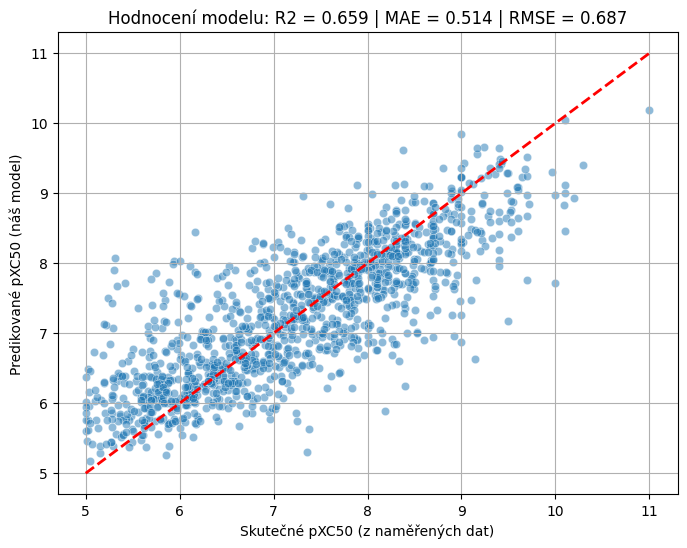

In [ ]:
# čím blíže že jsou ty tečky červené čáře tím je to lepší 
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=predictions, alpha=0.5)

plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)

plt.xlabel('Skutečné pXC50 (z naměřených dat)')
plt.ylabel('Predikované pXC50 (náš model)')
plt.title(f'Hodnocení modelu: R2 = {r2:.3f} | MAE = {mae:.3f} | RMSE = {rmse:.3f}')
# přesnost v %
# v průměru se seknu o
# přísnější přesnost více trestá velké chyby
plt.grid(True)
plt.show()